In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("netflix_titles.xlsx")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

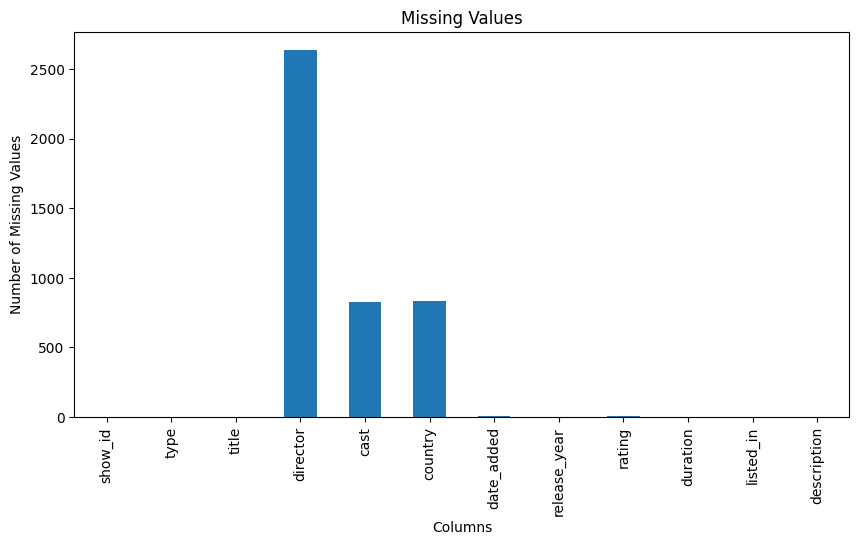

In [9]:
plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind="bar")
plt.title("Missing Values")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

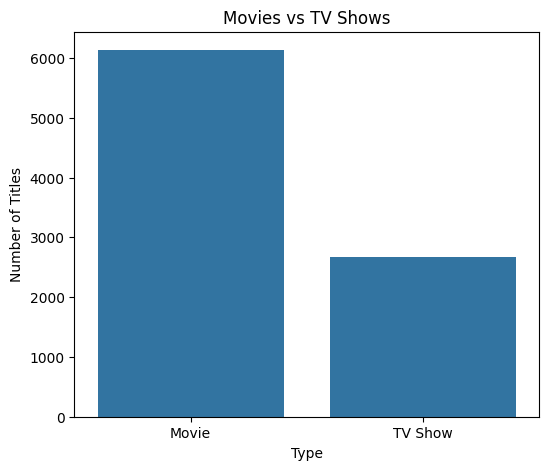

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.show()

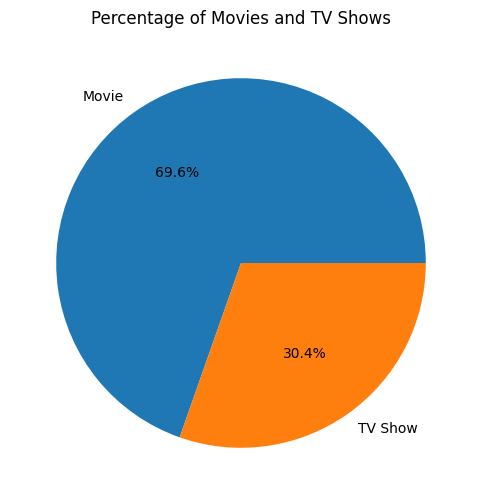

In [14]:
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Percentage of Movies and TV Shows")
plt.ylabel("")
plt.show()

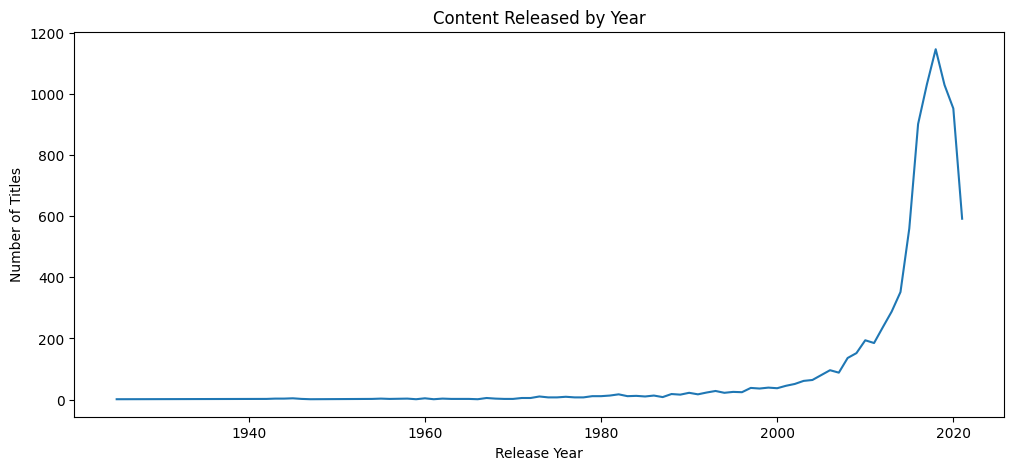

In [15]:
year_count = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_count.index, year_count.values)
plt.title("Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

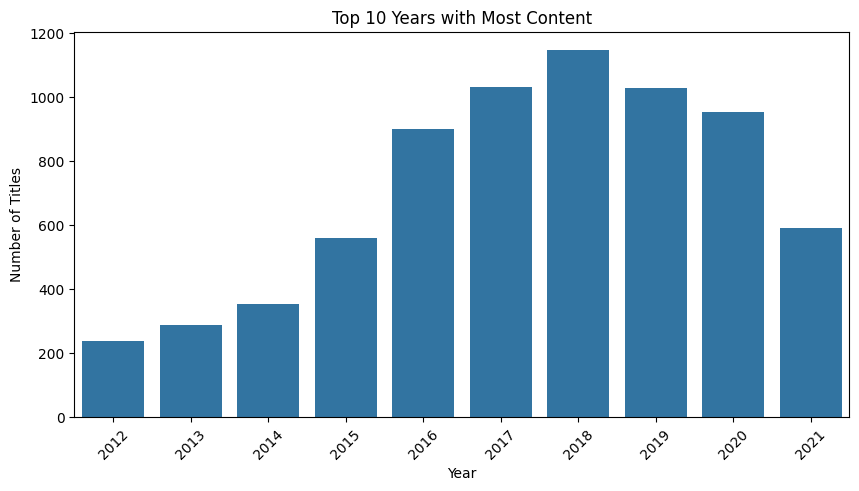

In [16]:
top_years = df["release_year"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_years.index,
    y=top_years.values
)
plt.title("Top 10 Years with Most Content")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [17]:
#  Rating analysis
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

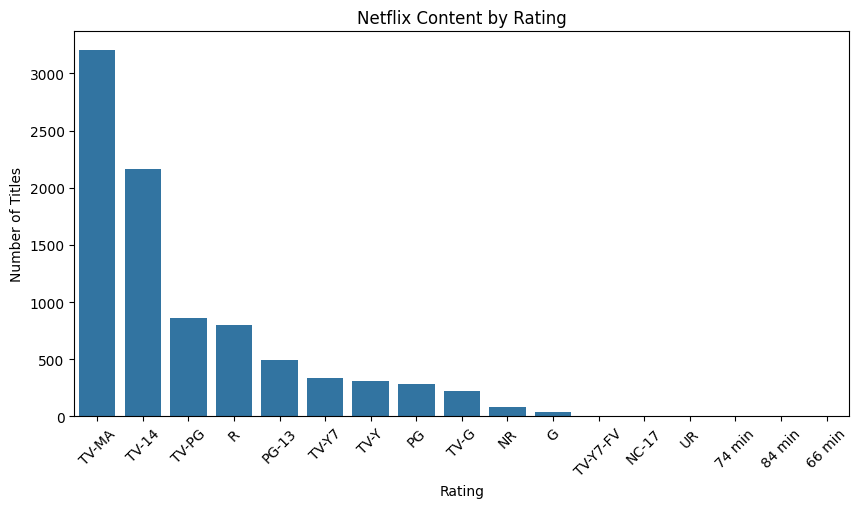

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)
plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [19]:
countries = df["country"].dropna().str.split(", ").explode()

top_countries = countries.value_counts().head(10)

top_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

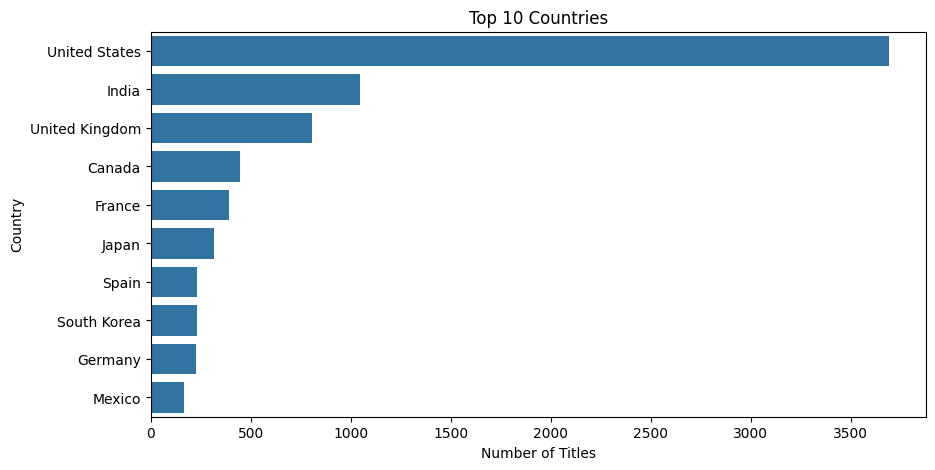

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [21]:
genres = df["listed_in"].dropna().str.split(", ").explode()

top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

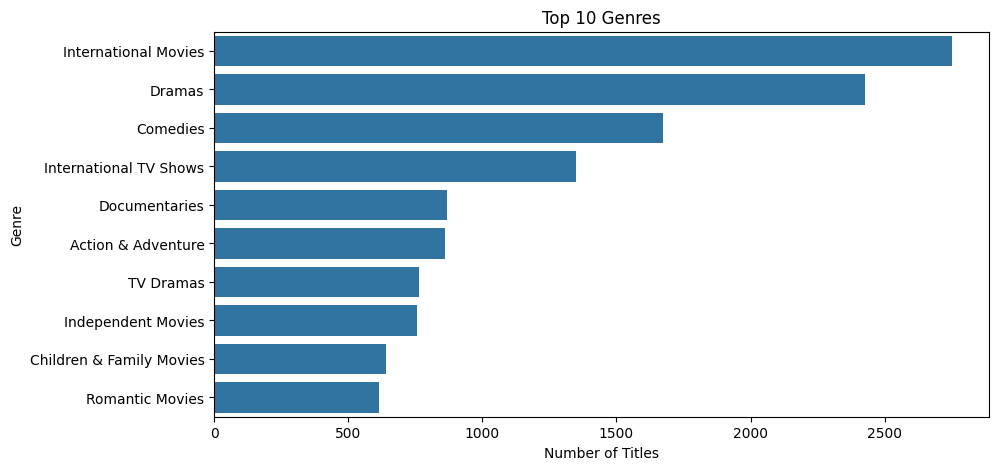

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

In [23]:
# Movies and TV Shows by Year
year_type = pd.crosstab(
    df["release_year"],
    df["type"]
)

year_type.tail(20)

type,Movie,TV Show
release_year,,
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23
2009,118,34
2010,154,40


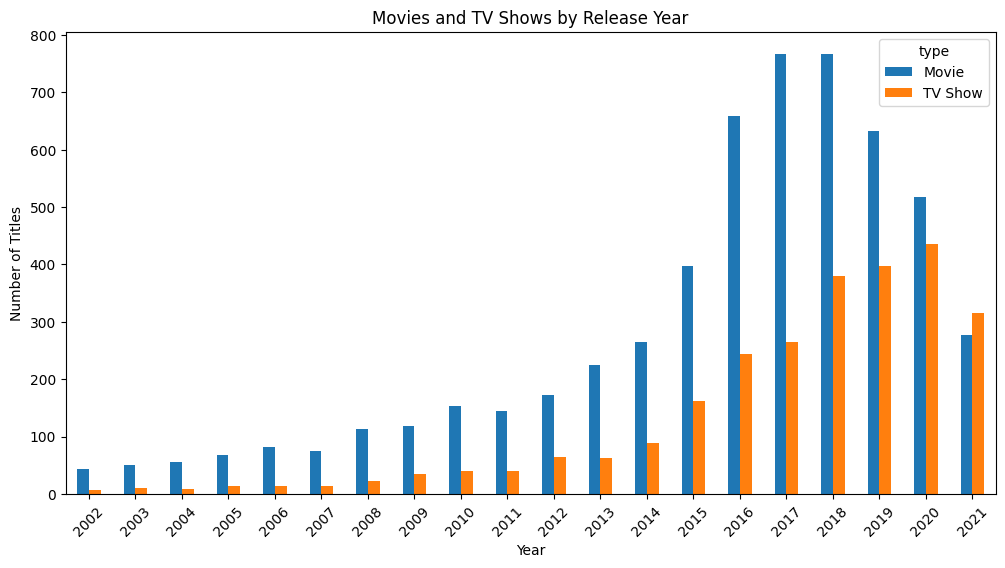

In [24]:
year_type.tail(20).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Movies and TV Shows by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [25]:
# Top Directors
directors = df["director"].dropna().str.split(", ").explode()

top_directors = directors.value_counts().head(10)

top_directors


director
Rajiv Chilaka          22
Jan Suter              21
RaÃºl Campos           19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

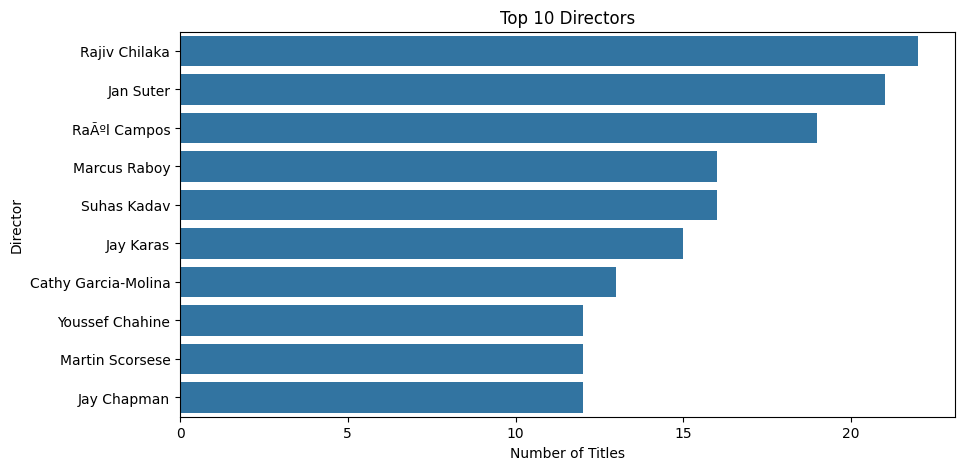

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)
plt.title("Top 10 Directors")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

In [27]:
# Movie Duration
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = movies["duration"].str.extract(
    "(\d+)"
).astype(float)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\User\AppData\Local\Temp\ipykernel_3144\3435510655.py:5: SyntaxWarning: invalid escape sequence '\d'
  "(\d+)"


In [28]:
movies["duration_min"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

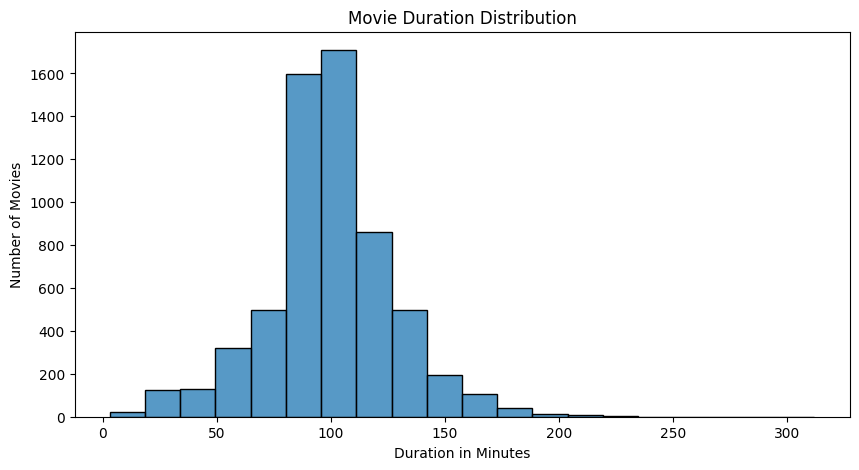

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(
    movies["duration_min"].dropna(),
    bins=20
)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")
plt.show()

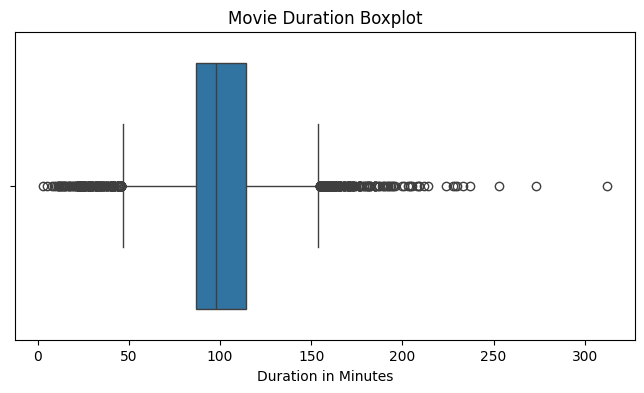

In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x=movies["duration_min"]
)
plt.title("Movie Duration Boxplot")
plt.xlabel("Duration in Minutes")
plt.show()

In [31]:
# TV Show Seasons
tv = df[df["type"] == "TV Show"].copy()

tv["seasons"] = tv["duration"].str.extract(
    "(\d+)"
).astype(float)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\User\AppData\Local\Temp\ipykernel_3144\3200323302.py:5: SyntaxWarning: invalid escape sequence '\d'
  "(\d+)"


In [32]:
tv["seasons"].value_counts().sort_index()

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

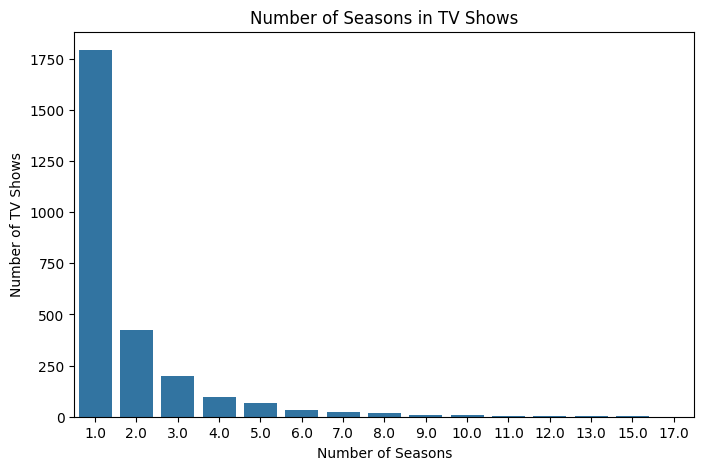

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=tv,
    x="seasons"
)
plt.title("Number of Seasons in TV Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.show()

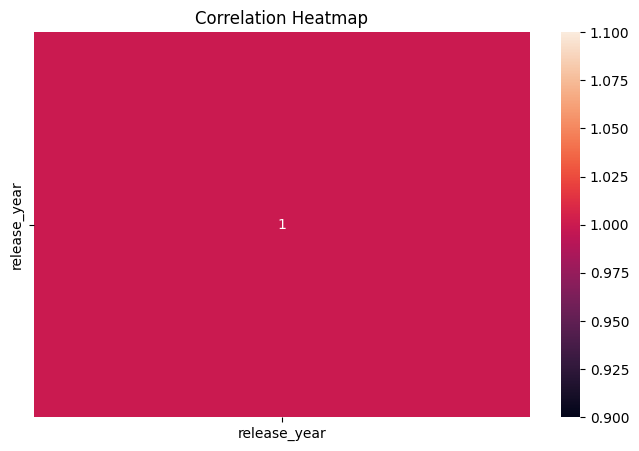

In [34]:
numeric_data = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8,5))
sns.heatmap(
    numeric_data.corr(),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

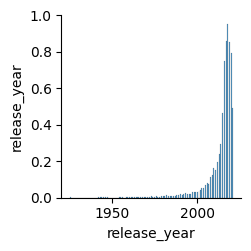

In [35]:
sns.pairplot(
    df.select_dtypes(include=np.number)
)

plt.show()

In [36]:
print("Total Titles:", len(df))
print("Total Movies:", (df["type"] == "Movie").sum())
print("Total TV Shows:", (df["type"] == "TV Show").sum())
print("Most Common Rating:", df["rating"].mode()[0])
print("Most Common Genre:", genres.mode()[0])
print("Top Country:", countries.mode()[0])

Total Titles: 8807
Total Movies: 6131
Total TV Shows: 2676
Most Common Rating: TV-MA
Most Common Genre: International Movies
Top Country: United States
